# Subscription-Trajectory Classification - 02b · Two-Stage Regression (renew -> ratio)

**Idea.** Same renew→movement decomposition as notebook 02, but Stage 2 is a
**regressor** rather than a classifier: predict a continuous volume signal, map the
predicted `vol_ratio` through the `0.50 / 1.50` band to a movement class, then compose
with the Stage-1 renewal probability. Two arms are compared — a **volume** arm
(`log1p(post_total_secs)` ÷ `pre_total_secs`) and a **ratio** arm (`log1p(vol_ratio)`).

**Protocol (airtight repeated holdout).** Sections 1-6 walk the pipeline once on a
single split for exposition; the **headline numbers come from the repeated-holdout
evaluation in §7**. There, for each seed in `U.RUN_SEEDS` we re-derive a fresh
user-grouped 15% holdout and 5 folds (`U.assign_run_split`, identical to 01/02 for the
same seed), **re-tune Stage 1, both Stage-2 regression arms, and the direct comparator
on that run's dev users only** (cached per seed), tune τ per arm on leakage-free dev
OOF, refit on all dev users, and evaluate once on the run's untouched holdout. The
two-stage **classifier** (02) is added as an external reference from
`clf_twostage_summary.csv` (same seeds → directly comparable). Scores are reported as
**mean ± standard error**. No `leakage_cols` ever enter `X`.


In [1]:
%load_ext autoreload
%autoreload 2
import warnings; warnings.filterwarnings('ignore')
import time, joblib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid', context='notebook')
import clf_utils as U
print('model classes   :', U.MODEL_CLASSES)
print('movement classes:', U.MOVEMENT_CLASSES)


model classes   : ['CHURN', 'CONTRACTION', 'STABLE', 'EXPANSION']
movement classes: ['CONTRACTION', 'STABLE', 'EXPANSION']


## 1 · Load data, targets & the ratio→class mapping

One row per `(msno, expiry_event)`, modellable rows only. We build the same
leakage-guarded base matrix as 01/02 and derive: the renewal target (`renewed`),
the 4-class target, and the two **regression** targets defined on renewers —
`log1p(post_total_secs)` (volume arm) and `log1p(vol_ratio)` (ratio arm). We also
define the deterministic map from a (predicted) volume ratio to a movement /
4-class code using the same `0.50 / 1.50` band as the label rule.


In [2]:
VOL_LOW, VOL_HIGH = 0.50, 1.50   # movement band; must match the ClassEngineering label rule

df = U.load_events('base', modellable_only=True, extra_cols=['post_total_secs'])
X  = U.build_X(df, 'base')
y_multi = U.y_multiclass(df)
y_renew = df['renewed'].to_numpy().astype(int)

# pre_total_secs is a known-at-E base feature (safe); post_total_secs / vol_ratio are targets only.
pre_secs = df['pre_total_secs'].to_numpy(dtype='float64')

# Contract: renewed==0 is exactly CHURN; renewed==1 is exactly the 3 movement classes
chk = pd.crosstab(df['renewed'], df['label'])
assert chk.loc[0, 'CHURN'] == (y_renew == 0).sum() and chk.drop(columns='CHURN').loc[0].sum() == 0
assert chk.loc[1, 'CHURN'] == 0

MOVE_TO_MULTI = np.array([U.CLASS_TO_CODE[c] for c in U.MOVEMENT_CLASSES])

def ratio_to_move(ratio):
    """Volume ratio -> movement code (index into U.MOVEMENT_CLASSES) via the label band."""
    r = np.asarray(ratio, dtype='float64')
    mv = np.full(len(r), U.MOVE_TO_CODE['STABLE'], dtype=int)
    mv[r < VOL_LOW]  = U.MOVE_TO_CODE['CONTRACTION']
    mv[r > VOL_HIGH] = U.MOVE_TO_CODE['EXPANSION']
    return mv

def ratio_to_multi(ratio):
    return MOVE_TO_MULTI[ratio_to_move(ratio)]

def derive_class(p_renew, ratio_hat, tau):
    """Compose stage 1 (renew prob vs threshold tau) with the ratio-derived movement class."""
    return np.where(p_renew < tau, U.CLASS_TO_CODE['CHURN'], ratio_to_multi(ratio_hat))

# Convert a stage-2 prediction back to a volume ratio (arm-dependent inverse transform)
def ratio_from_pred(pred, pre_, mode):
    if mode == 'volume':
        return np.expm1(pred) / np.maximum(pre_, 1e-9)   # regressed log post-volume / known pre-volume
    return np.expm1(pred)                                # mode == 'ratio' -> regressed log ratio

print('rows:', f'{len(df):,}', '| features:', X.shape[1])
print('renewal rate (dev): %.4f' % y_renew[U.dev_mask(df)].mean())
print('movement balance among renewers (dev):')
print(df.loc[U.dev_mask(df) & (df['renewed'] == 1), 'label'].value_counts(normalize=True).round(4))


rows: 3,784,500 | features: 29
renewal rate (dev): 0.9576
movement balance among renewers (dev):
label
STABLE         0.6588
EXPANSION      0.1806
CONTRACTION    0.1606
Name: proportion, dtype: float64


## 2 · Model adapters, CV helpers & per-stage subsamples

LightGBM is the workhorse (a classifier for Stage 1, a regressor for Stage 2). The
Stage-1 classifier is scored by renew/churn macro-F1; the Stage-2 **regressors** are
scored by the **derived movement macro-F1** — we map each fold's predicted ratio
through the label band and score the resulting `CONTRACTION/STABLE/EXPANSION` — so
the sweep optimises the regressor for the classification objective (with RMSE
reported alongside). Stage-1 sweeps over a dev subsample; Stage-2 over a renewer-only
subsample (folds stay user-disjoint).


In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (f1_score, balanced_accuracy_score, roc_auc_score,
                             average_precision_score, mean_squared_error)
from lightgbm import LGBMClassifier, LGBMRegressor

CATS = U.categorical_columns(X)
NUMS = U.numeric_columns(X)

def make_lgbm(**kw):
    params = dict(n_estimators=400, learning_rate=0.05, num_leaves=63,
                  class_weight='balanced', n_jobs=-1, random_state=U.RANDOM_STATE, verbose=-1)
    params.update(kw)
    return LGBMClassifier(**params)

def make_lgbm_reg(**kw):
    params = dict(objective='regression', n_estimators=400, learning_rate=0.05, num_leaves=63,
                  n_jobs=-1, random_state=U.RANDOM_STATE, verbose=-1)
    params.update(kw)
    return LGBMRegressor(**params)

def make_logit():
    num = Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())])
    cat = OneHotEncoder(handle_unknown='ignore', min_frequency=50)
    pre = ColumnTransformer([('num', num, NUMS), ('cat', cat, CATS)])
    return Pipeline([('pre', pre), ('clf', LogisticRegression(max_iter=300, class_weight='balanced'))])

def fit_default(m, Xt, yt): m.fit(Xt, yt); return m

def run_cv(make, fitfn, dfs_, Xs_, ys_, n_folds=3):
    f1s, bals, t0 = [], [], time.time()
    for k, (tr, va) in enumerate(U.cv_folds(dfs_)):
        if k >= n_folds: break
        m = fitfn(make(), Xs_.iloc[tr], ys_[tr])
        p = np.asarray(m.predict(Xs_.iloc[va])).astype(int)
        f1s.append(f1_score(ys_[va], p, average='macro'))
        bals.append(balanced_accuracy_score(ys_[va], p))
    return dict(macro_f1=float(np.mean(f1s)), macro_f1_std=float(np.std(f1s)),
                balanced_acc=float(np.mean(bals)), secs=round(time.time()-t0, 1))

def run_cv_reg(make, dfs_, Xs_, target, pre_, true_move, mode, n_folds=3):
    """Regression CV scored by the DERIVED movement macro-F1 (+ RMSE in the regressed space)."""
    f1s, rmses, t0 = [], [], time.time()
    for k, (tr, va) in enumerate(U.cv_folds(dfs_)):
        if k >= n_folds: break
        m = make().fit(Xs_.iloc[tr], target[tr])
        pred = m.predict(Xs_.iloc[va])
        ratio_hat = ratio_from_pred(pred, pre_[va], mode)
        f1s.append(f1_score(true_move[va], ratio_to_move(ratio_hat), average='macro'))
        rmses.append(float(np.sqrt(mean_squared_error(target[va], pred))))
    return dict(move_f1=float(np.mean(f1s)), move_f1_std=float(np.std(f1s)),
                rmse=float(np.mean(rmses)), secs=round(time.time()-t0, 1))

LGBM_GRID = dict(n_estimators=[300, 500, 800], learning_rate=[0.03, 0.05, 0.1],
                 num_leaves=[31, 63, 127, 255], min_child_samples=[20, 50, 100, 200],
                 colsample_bytree=[0.7, 0.85, 1.0], subsample=[0.7, 0.85, 1.0],
                 reg_lambda=[0.0, 1.0, 5.0])

def _finalise(tdf):
    bp = {k: tdf.iloc[0][k] for k in LGBM_GRID}
    for k in ('n_estimators', 'num_leaves', 'min_child_samples'): bp[k] = int(bp[k])
    bp['subsample_freq'] = 1
    return bp

def lgbm_sweep(name, dfs_, Xs_, ys_, n_trials=16, seed=U.RANDOM_STATE, force=False):
    if U.has_sweep(name) and not force:
        c = U.load_sweep(name)
        print('loaded cached sweep %-20s best macroF1=%.4f' % (name, c['best_score']))
        return c['best_params'], pd.read_csv(U.SWEEP_DIR / f'{name}_trials.csv')
    rng = np.random.default_rng(seed); trials = []
    for i in range(n_trials):
        cfg = {k: rng.choice(v).item() for k, v in LGBM_GRID.items()}
        r = run_cv(lambda: make_lgbm(**dict(cfg, subsample_freq=1)), fit_default, dfs_, Xs_, ys_, n_folds=3)
        r.update(cfg); trials.append(r)
        print(f"  trial {i:02d} macroF1={r['macro_f1']:.4f}")
    tdf = pd.DataFrame(trials).sort_values('macro_f1', ascending=False).reset_index(drop=True)
    bp = _finalise(tdf)
    U.save_sweep(name, bp, float(tdf.iloc[0]['macro_f1']), results=tdf.to_dict('records'),
                 meta={'n_trials': n_trials, 'subsample': int(len(dfs_)), 'cv_folds': 3})
    print('saved sweep cache:', name)
    return bp, tdf

def lgbm_reg_sweep(name, dfs_, Xs_, target, pre_, true_move, mode, n_trials=24, seed=U.RANDOM_STATE, force=False):
    if U.has_sweep(name) and not force:
        c = U.load_sweep(name)
        print('loaded cached sweep %-20s best moveF1=%.4f' % (name, c['best_score']))
        return c['best_params'], pd.read_csv(U.SWEEP_DIR / f'{name}_trials.csv')
    rng = np.random.default_rng(seed); trials = []
    for i in range(n_trials):
        cfg = {k: rng.choice(v).item() for k, v in LGBM_GRID.items()}
        r = run_cv_reg(lambda: make_lgbm_reg(**dict(cfg, subsample_freq=1)),
                       dfs_, Xs_, target, pre_, true_move, mode, n_folds=3)
        r.update(cfg); trials.append(r)
        print(f"  trial {i:02d} moveF1={r['move_f1']:.4f}  rmse={r['rmse']:.4f}")
    tdf = pd.DataFrame(trials).sort_values('move_f1', ascending=False).reset_index(drop=True)
    bp = _finalise(tdf)
    U.save_sweep(name, bp, float(tdf.iloc[0]['move_f1']), results=tdf.to_dict('records'),
                 meta={'n_trials': n_trials, 'subsample': int(len(dfs_)), 'cv_folds': 3, 'mode': mode})
    print('saved sweep cache:', name)
    return bp, tdf

# Subsamples: stage 1 over all dev; stage 2 over dev renewers only (folds stay user-disjoint)
dev  = df[U.dev_mask(df)].reset_index(drop=True)
Xdev = X[U.dev_mask(df)].reset_index(drop=True)
ymdev = U.y_multiclass(dev)
yrdev = dev['renewed'].to_numpy().astype(int)
s1 = U.stratified_subsample(dev, ymdev, 200_000)
dfs, Xs, ys_renew = dev.iloc[s1].reset_index(drop=True), Xdev.iloc[s1].reset_index(drop=True), yrdev[s1]

dev_r  = dev[yrdev == 1].reset_index(drop=True)
Xdev_r = Xdev[yrdev == 1].reset_index(drop=True)
move_dev_r = U.y_movement(dev_r)
s2 = U.stratified_subsample(dev_r, move_dev_r, 200_000)
dfs2, Xs2 = dev_r.iloc[s2].reset_index(drop=True), Xdev_r.iloc[s2].reset_index(drop=True)
pre2      = dfs2['pre_total_secs'].to_numpy(dtype='float64')
move2     = U.y_movement(dfs2)
logvol2   = np.log1p(np.clip(dfs2['post_total_secs'].to_numpy(dtype='float64'), 0, None))
logratio2 = np.log1p(np.clip(dfs2['vol_ratio'].to_numpy(dtype='float64'), 0, None))
print('stage-1 subsample:', f'{len(dfs):,}', '| stage-2 (renewers) subsample:', f'{len(dfs2):,}')


stage-1 subsample: 200,001 | stage-2 (renewers) subsample: 200,001


## 3 · Stage 1 — renewal classifier (shared with 02)

Identical Stage-1 task to notebook 02, so we reuse the cached `twostage_renew`
sweep (same data, same split) rather than re-tuning. Logistic baseline for context.


In [4]:
b1 = run_cv(make_logit, fit_default, dfs, Xs, ys_renew, n_folds=3)
print('logistic baseline  macroF1=%.4f  balAcc=%.4f' % (b1['macro_f1'], b1['balanced_acc']))
renew_params, renew_sweep = lgbm_sweep('twostage_renew', dfs, Xs, ys_renew, n_trials=16)
print('stage-1 best macroF1=%.4f' % renew_sweep.iloc[0]['macro_f1'])
print('stage-1 best params:', renew_params)
renew_sweep.head(8).round(4)


logistic baseline  macroF1=0.6018  balAcc=0.8359
loaded cached sweep twostage_renew       best macroF1=0.7173
stage-1 best macroF1=0.7173
stage-1 best params: {'n_estimators': 300, 'learning_rate': 0.1, 'num_leaves': 255, 'min_child_samples': 50, 'colsample_bytree': 0.85, 'subsample': 0.7, 'reg_lambda': 5.0, 'subsample_freq': 1}


,macro_f1,macro_f1_std,balanced_acc,secs,n_estimators,learning_rate,num_leaves,min_child_samples,colsample_bytree,subsample,reg_lambda
0,0.7173,0.0037,0.7588,40.4,300,0.10,255,50,0.85,0.70,5.0
1,0.7147,0.0033,0.8211,64.1,500,0.03,255,20,1.00,0.70,5.0
2,0.7110,0.0052,0.7120,47.2,800,0.10,127,20,1.00,0.85,1.0
3,0.7103,0.0006,0.8345,57.8,500,0.03,255,200,0.85,0.85,5.0
4,0.7097,0.0050,0.7258,55.4,800,0.10,127,50,1.00,0.70,5.0
5,0.7096,0.0007,0.7962,31.1,800,0.10,63,200,0.70,0.70,5.0
6,0.7078,0.0023,0.8084,17.3,300,0.10,127,50,0.85,1.00,0.0
7,0.6995,0.0034,0.8388,30.4,800,0.05,63,200,0.85,0.70,1.0


## 4 · Stage 1 final — held-out users

Refit the tuned Stage-1 classifier on all development users; report ROC-AUC / PR-AUC
(renewal is positive) and the renew/churn macro-F1 at the default 0.5 cut.


In [5]:
mask_dev, mask_ho = U.dev_mask(df), U.holdout_mask(df)
Xtr, Xho = X[mask_dev], X[mask_ho]
yr_tr = df.loc[mask_dev, 'renewed'].to_numpy().astype(int)
yr_ho = df.loc[mask_ho, 'renewed'].to_numpy().astype(int)

t0 = time.time(); stage1 = make_lgbm(**renew_params).fit(Xtr, yr_tr)
print('stage-1 fit on', f'{len(yr_tr):,}', 'rows in', round(time.time()-t0, 1), 's')
p_renew_ho = stage1.predict_proba(Xho)[:, 1]
print('renewal ROC-AUC: %.4f | PR-AUC: %.4f' % (
    roc_auc_score(yr_ho, p_renew_ho), average_precision_score(yr_ho, p_renew_ho)))
print('renew/churn macro-F1 @0.5: %.4f' % f1_score(yr_ho, (p_renew_ho >= 0.5).astype(int), average='macro'))


stage-1 fit on 3,215,995 rows in 24.9 s
renewal ROC-AUC: 0.9566 | PR-AUC: 0.9980
renew/churn macro-F1 @0.5: 0.6709


## 5 · Stage 2 — volume / ratio regression sweeps

Two competing regressors on the renewer-only subsample, both tuned on the **derived
movement macro-F1** (each fold's predicted ratio is mapped through the label band):

* **volume arm** — regress `log1p(post_total_secs)`, then `ratio = expm1(pred) / pre_total_secs`;
* **ratio arm** — regress `log1p(vol_ratio)` directly, then `ratio = expm1(pred)`.

A naive constant-prediction baseline anchors the bottom.


In [6]:
# Naive baseline: predict the training-mean target -> constant ratio -> single movement class
def naive_move_f1(target, pre_, true_move, mode):
    for tr, va in U.cv_folds(dfs2):
        c = float(np.mean(target[tr]))
        ratio_hat = ratio_from_pred(np.full(len(va), c), pre_[va], mode)
        return f1_score(true_move[va], ratio_to_move(ratio_hat), average='macro')
print('naive constant baseline (volume) moveF1=%.4f' % naive_move_f1(logvol2, pre2, move2, 'volume'))

vol_params, vol_sweep = lgbm_reg_sweep('02b_stage2_volume', dfs2, Xs2, logvol2, pre2, move2, 'volume', n_trials=24)
print('volume-arm best moveF1=%.4f  rmse(logvol)=%.4f' % (vol_sweep.iloc[0]['move_f1'], vol_sweep.iloc[0]['rmse']))
rat_params, rat_sweep = lgbm_reg_sweep('02b_stage2_ratio', dfs2, Xs2, logratio2, pre2, move2, 'ratio', n_trials=24)
print('ratio-arm  best moveF1=%.4f  rmse(logratio)=%.4f' % (rat_sweep.iloc[0]['move_f1'], rat_sweep.iloc[0]['rmse']))
print('\nvolume-arm best params:', vol_params)
print('ratio-arm  best params:', rat_params)
vol_sweep.head(6).round(4)


naive constant baseline (volume) moveF1=0.3638
  trial 00 moveF1=0.3633  rmse=1.1491
  trial 01 moveF1=0.3387  rmse=1.1320
  trial 02 moveF1=0.3781  rmse=1.1801
  trial 03 moveF1=0.3618  rmse=1.1403
  trial 04 moveF1=0.3433  rmse=1.1380
  trial 05 moveF1=0.3831  rmse=1.1740
  trial 06 moveF1=0.3460  rmse=1.1337
  trial 07 moveF1=0.3570  rmse=1.1491
  trial 08 moveF1=0.3495  rmse=1.1381
  trial 09 moveF1=0.3635  rmse=1.1428
  trial 10 moveF1=0.3427  rmse=1.1399
  trial 11 moveF1=0.3561  rmse=1.1376
  trial 12 moveF1=0.3481  rmse=1.1387
  trial 13 moveF1=0.3795  rmse=1.1567
  trial 14 moveF1=0.3576  rmse=1.1517
  trial 15 moveF1=0.3855  rmse=1.1899
  trial 16 moveF1=0.3650  rmse=1.1459
  trial 17 moveF1=0.3501  rmse=1.1363
  trial 18 moveF1=0.3693  rmse=1.1518
  trial 19 moveF1=0.3640  rmse=1.1477
  trial 20 moveF1=0.3441  rmse=1.1372
  trial 21 moveF1=0.3442  rmse=1.1320
  trial 22 moveF1=0.3391  rmse=1.1315
  trial 23 moveF1=0.3504  rmse=1.1418
saved sweep cache: 02b_stage2_volume
volu

,move_f1,move_f1_std,rmse,secs,n_estimators,learning_rate,num_leaves,min_child_samples,colsample_bytree,subsample,reg_lambda
0,0.3855,0.0019,1.1899,45.6,800,0.10,127,50,1.00,0.70,5.0
1,0.3831,0.0018,1.1740,29.4,300,0.10,255,50,0.85,0.70,5.0
2,0.3795,0.0003,1.1567,26.6,800,0.10,63,200,0.70,0.70,5.0
3,0.3781,0.0030,1.1801,40.6,800,0.10,127,20,1.00,0.85,1.0
4,0.3693,0.0019,1.1518,20.0,300,0.10,127,100,0.85,0.85,0.0
5,0.3650,0.0023,1.1459,33.8,500,0.05,127,100,0.70,0.70,0.0


## 6 · Stage 2 final — movement among held-out renewers

Refit both regression arms on all development renewers, predict the held-out
renewers, derive the movement class through the band, and report macro-F1 over
`CONTRACTION / STABLE / EXPANSION` for each arm.


In [8]:
mask_dev_r = mask_dev & (df['renewed'] == 1).to_numpy()
mask_ho_r  = mask_ho  & (df['renewed'] == 1).to_numpy()
pre_ho_r   = df.loc[mask_ho_r, 'pre_total_secs'].to_numpy(dtype='float64')
move_ho_r  = U.y_movement(df[mask_ho_r])

logvol_tr   = np.log1p(np.clip(df.loc[mask_dev_r, 'post_total_secs'].to_numpy(dtype='float64'), 0, None))
logratio_tr = np.log1p(np.clip(df.loc[mask_dev_r, 'vol_ratio'].to_numpy(dtype='float64'), 0, None))
t0 = time.time()
reg_vol = make_lgbm_reg(**vol_params).fit(X[mask_dev_r], logvol_tr)
reg_rat = make_lgbm_reg(**rat_params).fit(X[mask_dev_r], logratio_tr)
print('stage-2 regressors fit on', f'{mask_dev_r.sum():,}', 'renewers in', round(time.time()-t0, 1), 's')

ratio_vol_ho = ratio_from_pred(reg_vol.predict(X[mask_ho_r]), pre_ho_r, 'volume')
ratio_rat_ho = ratio_from_pred(reg_rat.predict(X[mask_ho_r]), pre_ho_r, 'ratio')
mv_vol = ratio_to_move(ratio_vol_ho)
mv_rat = ratio_to_move(ratio_rat_ho)
print('\nmovement macro-F1 among held-out renewers:')
print('  volume-arm : %.4f' % f1_score(move_ho_r, mv_vol, average='macro'))
print('  ratio-arm  : %.4f' % f1_score(move_ho_r, mv_rat, average='macro'))
print('\nvolume-arm movement report:')
print(U.report_df(move_ho_r, mv_vol, U.MOVEMENT_CLASSES).round(3))


stage-2 regressors fit on 3,079,644 renewers in 57.5 s

movement macro-F1 among held-out renewers:
  volume-arm : 0.3394
  ratio-arm  : 0.3454

volume-arm movement report:
              precision  recall  f1-score     support
CONTRACTION       0.398   0.096     0.155   87232.000
STABLE            0.673   0.970     0.795  358723.000
EXPANSION         0.595   0.036     0.069   98366.000
accuracy          0.661   0.661     0.661       0.661
macro avg         0.555   0.368     0.339  544321.000
weighted avg      0.615   0.661     0.561  544321.000


## 7 · Repeated-holdout evaluation — regression arms vs direct (5 runs, re-tuned per split)

Headline result. For each seed in `U.RUN_SEEDS` we stamp a fresh user-grouped 15%
holdout (`U.assign_run_split`), **re-tune Stage 1, the volume arm, the ratio arm and the
direct comparator on that run's dev users only** (cached per seed for overnight
resumability), tune the renewal threshold τ **per arm** on leakage-free dev OOF, refit
on all dev users, and evaluate once on the run's holdout. We record, per run: **02b
regress-volume**, **02b regress-ratio** and the **direct LightGBM comparator** (paired within
each run). Aggregated to mean ± SE in §7b, where the two-stage classifier (02) is
appended as an external reference from its own summary. This is the slow cell.

In [ ]:
taus = np.linspace(0.10, 0.90, 33)
run_records, perclass_records = [], []
rep = {}
t_all = time.time()
for ri, seed in enumerate(U.RUN_SEEDS):
    t0 = time.time()
    U.assign_run_split(df, seed)                      # fresh user-grouped 15% holdout + 5 folds
    mask_dev, mask_ho = U.dev_mask(df), U.holdout_mask(df)

    # dev subsamples from THIS run's dev users
    dev = df[mask_dev].reset_index(drop=True)
    Xdev = X[mask_dev].reset_index(drop=True)
    ymdev = U.y_multiclass(dev); yrdev = dev['renewed'].to_numpy().astype(int)
    s1 = U.stratified_subsample(dev, ymdev, 200_000, random_state=seed)
    dfs = dev.iloc[s1].reset_index(drop=True); Xs = Xdev.iloc[s1].reset_index(drop=True)
    ys_renew = yrdev[s1]; ys_multi_sub = ymdev[s1]
    dev_r = dev[yrdev == 1].reset_index(drop=True); Xdev_r = Xdev[yrdev == 1].reset_index(drop=True)
    move_dev_r = U.y_movement(dev_r)
    s2 = U.stratified_subsample(dev_r, move_dev_r, 200_000, random_state=seed)
    dfs2 = dev_r.iloc[s2].reset_index(drop=True); Xs2 = Xdev_r.iloc[s2].reset_index(drop=True)
    pre2 = dfs2['pre_total_secs'].to_numpy(dtype='float64'); move2 = U.y_movement(dfs2)
    logvol2   = np.log1p(np.clip(dfs2['post_total_secs'].to_numpy(dtype='float64'), 0, None))
    logratio2 = np.log1p(np.clip(dfs2['vol_ratio'].to_numpy(dtype='float64'), 0, None))

    # re-tune both arms + stage-1 + direct comparator on THIS run's dev only
    renew_params,  _ = lgbm_sweep(f'twostage_renew_run{seed}', dfs, Xs, ys_renew, n_trials=16, seed=seed)
    vol_params, _ = lgbm_reg_sweep(f'02b_stage2_volume_run{seed}', dfs2, Xs2, logvol2,   pre2, move2, 'volume', n_trials=24, seed=seed)
    rat_params, _ = lgbm_reg_sweep(f'02b_stage2_ratio_run{seed}',  dfs2, Xs2, logratio2, pre2, move2, 'ratio',  n_trials=24, seed=seed)
    direct_params, _ = lgbm_sweep(f'direct_lgbm_run{seed}', dfs, Xs, ys_multi_sub, n_trials=16, seed=seed)

    # refit on all dev users
    Xtr, Xho = X[mask_dev], X[mask_ho]
    yr_tr = df.loc[mask_dev, 'renewed'].to_numpy().astype(int)
    mask_dev_r = mask_dev & (df['renewed'] == 1).to_numpy()
    logvol_tr   = np.log1p(np.clip(df.loc[mask_dev_r, 'post_total_secs'].to_numpy(dtype='float64'), 0, None))
    logratio_tr = np.log1p(np.clip(df.loc[mask_dev_r, 'vol_ratio'].to_numpy(dtype='float64'), 0, None))
    stage1  = make_lgbm(**renew_params).fit(Xtr, yr_tr)
    reg_vol = make_lgbm_reg(**vol_params).fit(X[mask_dev_r], logvol_tr)
    reg_rat = make_lgbm_reg(**rat_params).fit(X[mask_dev_r], logratio_tr)
    direct  = make_lgbm(**direct_params).fit(Xtr, y_multi[mask_dev])

    # tune tau per arm on leakage-free dev OOF
    oof_pr = np.full(len(dfs), np.nan)
    for tr, va in U.cv_folds(dfs):
        s1m = make_lgbm(**renew_params).fit(Xs.iloc[tr], ys_renew[tr])
        oof_pr[va] = s1m.predict_proba(Xs.iloc[va])[:, 1]
    ym_sub = U.y_multiclass(dfs); cov = ~np.isnan(oof_pr)

    def oof_ratio_local(params, target_col, mode):
        o = np.full(len(dfs), np.nan)
        for tr, va in U.cv_folds(dfs):
            tr_r = np.asarray(tr)[dfs.iloc[tr]['renewed'].to_numpy() == 1]
            tgt = np.log1p(np.clip(dfs.iloc[tr_r][target_col].to_numpy(dtype='float64'), 0, None))
            m = make_lgbm_reg(**params).fit(Xs.iloc[tr_r], tgt)
            pre_va = dfs.iloc[va]['pre_total_secs'].to_numpy(dtype='float64')
            o[va] = ratio_from_pred(m.predict(Xs.iloc[va]), pre_va, mode)
        return o

    def tune_tau_local(ratio_oof):
        f1s = [f1_score(ym_sub[cov], derive_class(oof_pr[cov], ratio_oof[cov], t), average='macro') for t in taus]
        return float(taus[int(np.argmax(f1s))])

    tau_vol = tune_tau_local(oof_ratio_local(vol_params, 'post_total_secs', 'volume'))
    tau_rat = tune_tau_local(oof_ratio_local(rat_params, 'vol_ratio', 'ratio'))

    # evaluate once on this run's holdout
    y_multi_ho = y_multi[mask_ho]
    pre_ho = df.loc[mask_ho, 'pre_total_secs'].to_numpy(dtype='float64')
    p_renew_ho = stage1.predict_proba(Xho)[:, 1]
    ratio_vol_ho = ratio_from_pred(reg_vol.predict(Xho), pre_ho, 'volume')
    ratio_rat_ho = ratio_from_pred(reg_rat.predict(Xho), pre_ho, 'ratio')
    preds = {'02b regress-volume':          derive_class(p_renew_ho, ratio_vol_ho, tau_vol),
             '02b regress-ratio':           derive_class(p_renew_ho, ratio_rat_ho, tau_rat),
             'Direct LightGBM comparator':  np.asarray(direct.predict(Xho)).astype(int)}
    for mname, pr in preds.items():
        run_records.append({**U.score_block(y_multi_ho, pr), 'model': mname, 'run': ri,
                            'seed': int(seed), 'n_holdout': int(mask_ho.sum()),
                            'tau_vol': tau_vol, 'tau_rat': tau_rat})
        pcf = U.per_class_f1(y_multi_ho, pr, U.MODEL_CLASSES)
        perclass_records.append({**pcf.to_dict(), 'model': mname, 'run': ri, 'seed': int(seed)})

    if ri == 0:
        rep = dict(seed=int(seed), stage1=stage1, reg_vol=reg_vol, reg_rat=reg_rat, direct=direct,
                   renew_params=renew_params, vol_params=vol_params, rat_params=rat_params,
                   direct_params=direct_params, tau_vol=tau_vol, tau_rat=tau_rat,
                   y_multi_ho=y_multi_ho, pred_vol=preds['02b regress-volume'],
                   pred_rat=preds['02b regress-ratio'], pred_direct=preds['Direct LightGBM comparator'])
    print(f"run {ri} seed={seed} holdout={int(mask_ho.sum()):,} tau_vol={tau_vol:.2f} tau_rat={tau_rat:.2f}  "
          f"vol={U.score_block(y_multi_ho, preds['02b regress-volume'])['macro_f1']:.4f}  "
          f"rat={U.score_block(y_multi_ho, preds['02b regress-ratio'])['macro_f1']:.4f}  "
          f"direct={U.score_block(y_multi_ho, preds['Direct LightGBM comparator'])['macro_f1']:.4f}  ({time.time()-t0:.0f}s)")
print(f"\nAll {len(U.RUN_SEEDS)} runs done in {(time.time()-t_all)/60:.1f} min")

loaded cached sweep twostage_renew_run42 best macroF1=0.7186
  trial 00 moveF1=0.3586  rmse=1.1725
  trial 01 moveF1=0.3377  rmse=1.1531
  trial 02 moveF1=0.3749  rmse=1.1988
  trial 03 moveF1=0.3587  rmse=1.1617
  trial 04 moveF1=0.3405  rmse=1.1584
  trial 05 moveF1=0.3760  rmse=1.1940
  trial 06 moveF1=0.3445  rmse=1.1551
  trial 07 moveF1=0.3531  rmse=1.1708
  trial 08 moveF1=0.3487  rmse=1.1592
  trial 09 moveF1=0.3603  rmse=1.1646
  trial 10 moveF1=0.3389  rmse=1.1617
  trial 11 moveF1=0.3542  rmse=1.1585
  trial 12 moveF1=0.3468  rmse=1.1607
  trial 13 moveF1=0.3747  rmse=1.1792
  trial 14 moveF1=0.3535  rmse=1.1728
  trial 15 moveF1=0.3829  rmse=1.2098
  trial 16 moveF1=0.3615  rmse=1.1668
  trial 17 moveF1=0.3505  rmse=1.1588
  trial 18 moveF1=0.3664  rmse=1.1733
  trial 19 moveF1=0.3602  rmse=1.1709
  trial 20 moveF1=0.3424  rmse=1.1588
  trial 21 moveF1=0.3420  rmse=1.1542
  trial 22 moveF1=0.3376  rmse=1.1526
  trial 23 moveF1=0.3471  rmse=1.1636
saved sweep cache: 02b_stag

Per-run holdout macro-F1:
model  02b regress-volume  02b regress-ratio  Direct LightGBM comparator
run                                                                 
0                  0.3435             0.3454                  0.4349
1                  0.3519             0.3541                  0.4389
2                  0.3392             0.3423                  0.4398
3                  0.3536             0.3548                  0.4384
4                  0.3420             0.3456                  0.4377

Mean ± SE over 5 runs   (tau_vol~0.44, tau_rat~0.45):
                               macro_f1     balanced_acc         accuracy  \
model                                                                       
02b regress-volume      0.3461 ± 0.0028  0.4709 ± 0.0004  0.6063 ± 0.0025   
02b regress-ratio       0.3484 ± 0.0025  0.4742 ± 0.0006  0.6124 ± 0.0028   
Direct LightGBM comparator  0.4379 ± 0.0008  0.5728 ± 0.0005  0.4913 ± 0.0008   

                            weighted_f1  


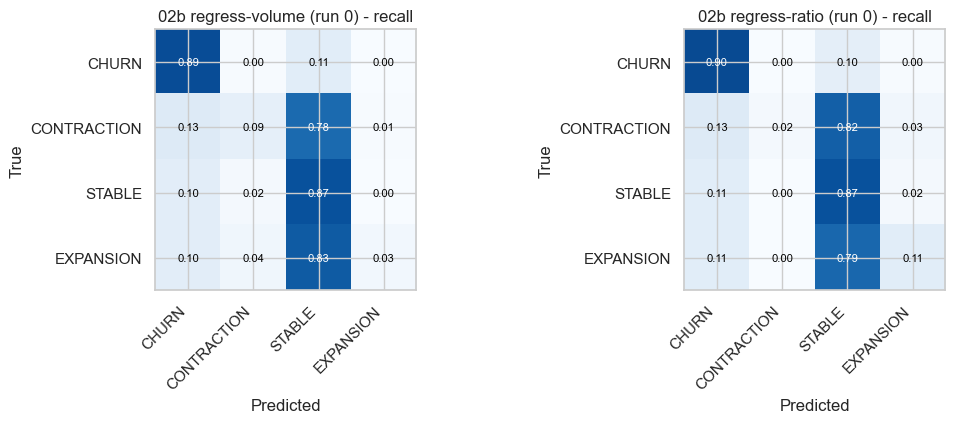

,macro_f1,balanced_acc,accuracy,weighted_f1
model,,,,
02b regress-volume,0.3461 ± 0.0028,0.4709 ± 0.0004,0.6063 ± 0.0025,0.5292 ± 0.0018
02b regress-ratio,0.3484 ± 0.0025,0.4742 ± 0.0006,0.6124 ± 0.0028,0.5350 ± 0.0016
Direct LightGBM comparator,0.4379 ± 0.0008,0.5728 ± 0.0005,0.4913 ± 0.0008,0.5186 ± 0.0008


In [ ]:
# 7b - aggregate the 5 runs into mean +/- SE and save
runs_df = pd.DataFrame(run_records)
order = ['02b regress-volume', '02b regress-ratio', 'Direct LightGBM comparator']
metrics = ['macro_f1', 'balanced_acc', 'accuracy', 'weighted_f1']
summary = U.agg_mean_se(runs_df, 'model', metrics).set_index('model').reindex(order)
tau_vol_mean = runs_df['tau_vol'].mean(); tau_rat_mean = runs_df['tau_rat'].mean()

print('Per-run holdout macro-F1:')
print(runs_df.pivot(index='run', columns='model', values='macro_f1')[order].round(4))
print(f'\nMean \u00b1 SE over {len(U.RUN_SEEDS)} runs   (tau_vol~{tau_vol_mean:.2f}, tau_rat~{tau_rat_mean:.2f}):')
show = pd.DataFrame({
    m: summary.apply(lambda r, m=m: f"{r[f'{m}_mean']:.4f} \u00b1 {r[f'{m}_se']:.4f}", axis=1)
    for m in metrics})
print(show)

# Champion 02b arm = higher mean holdout macro-F1
champ_arm = 'volume' if summary.loc['02b regress-volume', 'macro_f1_mean'] >= summary.loc['02b regress-ratio', 'macro_f1_mean'] else 'ratio'
champ_name = f'regress-{champ_arm}'
print(f'\n02b champion arm (max mean macro-F1): {champ_name}')

# Per-class F1 mean +/- SE per model
pc_df = pd.DataFrame(perclass_records)
pc_summary = U.agg_mean_se(pc_df, 'model', U.MODEL_CLASSES).set_index('model').reindex(order)
print('\nPer-class F1 (mean over runs):')
print(pd.DataFrame({c: pc_summary[f'{c}_mean'] for c in U.MODEL_CLASSES}).round(3))

# External reference: two-stage classifier (02), same seeds -> directly comparable
ref_path = U.DATA / 'clf_twostage_summary.csv'
vs_others = summary.copy()
if ref_path.exists():
    ts = pd.read_csv(ref_path).set_index('model')
    keep = [m for m in ['Two-stage (tuned)', 'Two-stage (arg-max)'] if m in ts.index]
    if keep:
        vs_others = pd.concat([summary, ts.loc[keep, summary.columns]])
        print('\nExternal reference rows appended from clf_twostage_summary.csv:', keep)
else:
    print('\nnote: clf_twostage_summary.csv not found - run notebook 02 first for the two-stage reference')

# Persist raw per-run tables + aggregated summaries
runs_df.to_csv(U.DATA / 'clf_02b_runs.csv', index=False)
summary.reset_index().to_csv(U.DATA / 'clf_02b_summary.csv', index=False)
pc_df.to_csv(U.DATA / 'clf_02b_perclass_runs.csv', index=False)
pc_summary.reset_index().to_csv(U.DATA / 'clf_02b_perclass_summary.csv', index=False)
# backward-compatible names (now mean-over-runs, incl. 02 reference rows)
vs_others.reset_index().to_csv(U.DATA / 'clf_02b_vs_others.csv', index=False)
pd.DataFrame({c: pc_summary[f'{c}_mean'] for c in U.MODEL_CLASSES}).round(4).to_csv(
    U.DATA / 'clf_02b_perclass_f1.csv')

# Representative run-0 confusion: both arms
fig, ax = plt.subplots(1, 2, figsize=(11, 4.4))
U.plot_confusion(rep['y_multi_ho'], rep['pred_vol'], U.MODEL_CLASSES, ax=ax[0],
                 title='Two-stage regression (volume): recall', normalize='true')
U.plot_confusion(rep['y_multi_ho'], rep['pred_rat'], U.MODEL_CLASSES, ax=ax[1],
                 title='Two-stage regression (ratio): recall', normalize='true')
plt.tight_layout(); plt.savefig(U.PLOTS / 'clf_02b_confusion.png', dpi=130); plt.show()
show

## 8 · Walk-forward validation — additional diagnostic (not reported in the dissertation)

Expanding window by `month_idx`: at each step refit the Stage-1 classifier and the
champion Stage-2 regressor on `month_idx <= t`, derive the 4-class outcome on `t+1`
at the tuned τ, and track temporal stability. This is a supplementary robustness check
and is not part of the reported dissertation results.

train<= 0  test 1: macroF1=0.3667  balAcc=0.4220
train<= 1  test 2: macroF1=0.3621  balAcc=0.4542
train<= 2  test 3: macroF1=0.3652  balAcc=0.4676
train<= 3  test 4: macroF1=0.3390  balAcc=0.4118
train<= 4  test 5: macroF1=0.3558  balAcc=0.4750


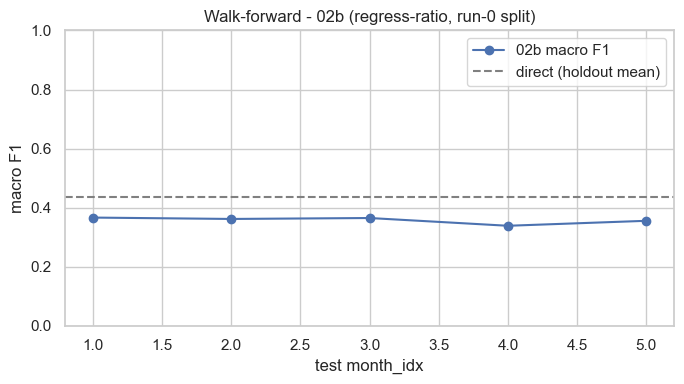

,accuracy,balanced_acc,macro_f1,weighted_f1,test_month,test_n
0,0.6247,0.4220,0.3667,0.5411,1,529419
1,0.6278,0.4542,0.3621,0.5476,2,543482
2,0.6366,0.4676,0.3652,0.5545,3,545571
3,0.6247,0.4118,0.3390,0.5476,4,551732
4,0.6198,0.4750,0.3558,0.5381,5,565623


In [ ]:
# Walk-forward is a temporal-stability diagnostic; pin to the run-0 split + champion arm params.
U.assign_run_split(df, U.RUN_SEEDS[0])
renew_params = rep['renew_params']
champ_params = rep['vol_params'] if champ_arm == 'volume' else rep['rat_params']
champ_tau    = rep['tau_vol'] if champ_arm == 'volume' else rep['tau_rat']
target_col   = 'post_total_secs' if champ_arm == 'volume' else 'vol_ratio'
direct_ref_f1 = summary.loc['Direct LightGBM comparator', 'macro_f1_mean']

wf = []
for tr, tst, t in U.walk_forward_splits(df):
    s1 = make_lgbm(**renew_params).fit(X.iloc[tr], df.iloc[tr]['renewed'].to_numpy().astype(int))
    rr = np.asarray(tr)[df.iloc[tr]['renewed'].to_numpy() == 1]
    tgt = np.log1p(np.clip(df.iloc[rr][target_col].to_numpy(dtype='float64'), 0, None))
    s2 = make_lgbm_reg(**champ_params).fit(X.iloc[rr], tgt)
    pr = s1.predict_proba(X.iloc[tst])[:, 1]
    pre_tst = df.iloc[tst]['pre_total_secs'].to_numpy(dtype='float64')
    ratio_hat = ratio_from_pred(s2.predict(X.iloc[tst]), pre_tst, champ_arm)
    pred = derive_class(pr, ratio_hat, champ_tau)
    s = U.score_block(U.y_multiclass(df.iloc[tst]), pred)
    s['test_month'] = t + 1; s['test_n'] = len(tst); wf.append(s)
    print(f"train<= {t}  test {t+1}: macroF1={s['macro_f1']:.4f}  balAcc={s['balanced_acc']:.4f}")
wf_df = pd.DataFrame(wf)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(wf_df['test_month'], wf_df['macro_f1'], 'o-', label='two-stage regression macro-F1')
ax.axhline(direct_ref_f1, ls='--', c='grey', label='direct (holdout mean)')
ax.set_xlabel('test month'); ax.set_ylabel('macro-F1'); ax.set_ylim(0, 1); ax.legend()
ax.set_title('Walk-forward stability: two-stage regression (' + champ_name + ')')
plt.tight_layout(); plt.savefig(U.PLOTS / 'clf_02b_walkforward.png', dpi=130); plt.show()
wf_df.round(4)

## 9 · Persist artifacts & summary

In [15]:
joblib.dump(rep['stage1'],  U.DATA / 'clf_02b_stage1_renew.joblib')     # representative run-0 fits
joblib.dump(rep['reg_vol'], U.DATA / 'clf_02b_stage2_volume.joblib')
joblib.dump(rep['reg_rat'], U.DATA / 'clf_02b_stage2_ratio.joblib')
wf_df.round(4).to_csv(U.DATA / 'clf_02b_walkforward.csv', index=False)
pd.DataFrame([{'champion_arm': champ_arm, 'tau_volume_mean': tau_vol_mean, 'tau_ratio_mean': tau_rat_mean,
               'n_runs': len(U.RUN_SEEDS), 'seeds': str(U.RUN_SEEDS),
               **{f'renew_{k}': v for k, v in rep['renew_params'].items()},
               **{f'vol_{k}': v for k, v in rep['vol_params'].items()},
               **{f'rat_{k}': v for k, v in rep['rat_params'].items()}}]).to_csv(
    U.DATA / 'clf_02b_config.csv', index=False)
print('Saved 02b artifacts to', U.DATA)
print('Per-seed sweeps cached:', [p.name for p in sorted(U.SWEEP_DIR.glob('02b_*_run*.json'))])
print(f'\nHeadline (mean \u00b1 SE over {len(U.RUN_SEEDS)} runs):')
for m in order:
    print(f"  {m:26s} macro-F1 = {summary.loc[m, 'macro_f1_mean']:.4f} \u00b1 {summary.loc[m, 'macro_f1_se']:.4f}")
print(f'02b champion arm: {champ_name}')


Saved 02b artifacts to <repo>/KKBoxData
Per-seed sweeps cached: ['02b_stage2_ratio_run42.json', '02b_stage2_ratio_run43.json', '02b_stage2_ratio_run44.json', '02b_stage2_ratio_run45.json', '02b_stage2_ratio_run46.json', '02b_stage2_volume_run42.json', '02b_stage2_volume_run43.json', '02b_stage2_volume_run44.json', '02b_stage2_volume_run45.json', '02b_stage2_volume_run46.json']

Headline (mean ± SE over 5 runs):
  02b regress-volume         macro-F1 = 0.3461 ± 0.0028
  02b regress-ratio          macro-F1 = 0.3484 ± 0.0025
  Direct LightGBM comparator     macro-F1 = 0.4379 ± 0.0008
02b champion arm: regress-ratio
